<a href="https://colab.research.google.com/github/robertrichard86/Avalia-o-Otimza-o-PI4/blob/main/Avalia%C3%A7%C3%A3o_e_Otimiza%C3%A7%C3%A3o_PI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Configuração do Ambiente e Importação de Bibliotecas

Esta célula inicial importa todas as bibliotecas necessárias para o projeto.

Isso inclui `Pandas` para manipulação de dados, `NLTK` para processamento de texto, `Scikit-learn` para vetorização (TF-IDF), modelagem (SVM, KNN, etc.) e avaliação (métricas, validação cruzada). Também carregamos `Matplotlib` e `Seaborn` para a visualização gráfica dos resultados e configuramos os avisos para uma saída mais limpa.

In [27]:
import pandas as pd
import nltk
import io
from google.colab import files, output
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
import warnings
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Ignora avisos futuros do Scikit-learn (apenas para limpeza)
warnings.filterwarnings('ignore', category=FutureWarning)

# 2. Download de Recursos NLTK

Esta célula baixa os pacotes necessários do NLTK (Natural Language Toolkit). O principal recurso aqui é o **'punkt'**, que é o tokenizador de sentenças pré-treinado. Ele foi essencial para a etapa anterior, onde dividimos os textos completos das críticas em sentenças individuais para a rotulagem.

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# 3. Upload dos Arquivos de Crítica Processados

Esta célula inicia o pipeline de preparação de dados.

Ela utiliza o assistente de arquivos do Google Colab para carregar os 3 `.csv` (um para cada site de crítica) que contêm os textos originais. Estes arquivos são a matéria-prima para a próxima etapa, onde extrairemos e segmentaremos as sentenças.

In [ ]:
print("Por favor, faça o upload dos 3 arquivos .csv processados:")
print("(adorocinema_processado.csv, omelete_processado.csv, plano_critico_processado.csv)")
uploaded = files.upload()

Por favor, faça o upload dos 3 arquivos .csv processados:
(adorocinema_processado.csv, omelete_processado.csv, plano_critico_processado.csv)


Saving adorocinema_processado.csv to adorocinema_processado.csv
Saving omelete_processado.csv to omelete_processado.csv
Saving plano_critico_processado.csv to plano_critico_processado.csv


# 4. Segmentação de Sentenças e Exportação para Rotulagem

Esta célula é o núcleo da nossa engenharia de dados.

Ela lê os arquivos carregados na etapa anterior, extrai a coluna de texto original (`texto_original`) e usa o tokenizador `nltk.sent_tokenize` para quebrar as críticas (que eram um texto único) em sentenças individuais.

Após limpar cada sentença, o código as agrupa em um novo DataFrame e o salva como `sentencas_para_rotular.csv`, que é o arquivo que usaremos para o "Assistente de Rotulagem" na próxima etapa.

In [ ]:
all_sentences = []

print("\n--- Processando arquivos... ---")

# Itera sobre os arquivos que você acabou de enviar
for file_name, file_content in uploaded.items():
    print(f"Lendo '{file_name}'...")

    # Lê o CSV enviado
    df = pd.read_csv(io.BytesIO(file_content))

    # Extrai a fonte (ex: "AdoroCinema") e o texto da primeira linha
    # (Sabemos que cada arquivo tem apenas 1 linha)
    if not df.empty:
        fonte = df['fonte'].iloc[0]
        texto_original = df['texto_original'].iloc[0]

        # Quebra o texto original em sentenças
        sentencas = nltk.sent_tokenize(texto_original, language='portuguese')

        # Adiciona cada sentença na nossa lista
        for sent in sentencas:
            # Limpa espaços em branco extras (ex: \n)
            sentenca_limpa = sent.strip().replace('\n', ' ')
            if sentenca_limpa: # Garante que não é uma linha vazia
                all_sentences.append({'fonte': fonte, 'sentenca': sentenca_limpa})

print("\n--- Processamento concluído. ---")

# Cria um novo DataFrame com todas as sentenças
df_para_rotular = pd.DataFrame(all_sentences)

# Mostra as primeiras linhas e a contagem total de sentenças
print("\n--- Amostra do novo dataset de sentenças ---")
print(df_para_rotular.head())
print("\n--- Informações ---")
df_para_rotular.info()


# --- Etapa 2: Exportação para Rotulagem ---

# Define o nome do arquivo de saída
output_filename = 'sentencas_para_rotular.csv'

# Salva o DataFrame em um novo arquivo CSV (usando utf-8-sig para compatibilidade com Excel)
df_para_rotular.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"\n--- Exportação Concluída ---")
print(f"Arquivo '{output_filename}' criado com sucesso.")

# Faz o download automático do arquivo para sua máquina local
files.download(output_filename)

print(f"O download de '{output_filename}' deve começar automaticamente.")
print("Verifique sua pasta de downloads.")


--- Processando arquivos... ---
Lendo 'adorocinema_processado.csv'...
Lendo 'omelete_processado.csv'...
Lendo 'plano_critico_processado.csv'...

--- Processamento concluído. ---

--- Amostra do novo dataset de sentenças ---
         fonte                                           sentenca
0  AdoroCinema  Alegria e Tristeza  A Pixar conseguiu, mais um...
1  AdoroCinema  Ao longo dos anos, o estúdio fez fama graças à...
2  AdoroCinema  Assim foi com Toy Story (o mundo dos brinquedo...
3  AdoroCinema  Após um período de vacas magras, em que até fe...
4  AdoroCinema  Nenhum outro filme exibido no Festival de Cann...

--- Informações ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   fonte     75 non-null     object
 1   sentenca  75 non-null     object
dtypes: object(2)
memory usage: 1.3+ KB

--- Exportação Concluída ---
Arquivo 'sentencas_para_rotular.cs

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

O download de 'sentencas_para_rotular.csv' deve começar automaticamente.
Verifique sua pasta de downloads.


# 5. Assistente Interativo para Rotulagem Manual

Esta é a etapa mais crítica da preparação dos dados: a criação do **"Ground Truth"** (o nosso "gabarito").

Este código funciona como um assistente interativo:
1.  Ele faz o upload do arquivo `sentencas_para_rotular.csv` (criado na etapa anterior).
2.  Itera por cada sentença, uma de cada vez.
3.  Pede ao usuário (nós) para classificar a sentença digitando `1` (Positivo), `2` (Negativo) ou `3` (Neutro).
4.  Ao final, ele compila todas as respostas em uma nova coluna (`polaridade`) e salva o resultado no arquivo final `sentencas_rotuladas.csv`, que será usado para treinar os modelos.

In [ ]:
print("Por favor, faça o upload do arquivo 'sentencas_para_rotular.csv' (gerado na etapa anterior).")
uploaded = files.upload()

# Pega o nome do arquivo que você enviou
file_name = list(uploaded.keys())[0]

# Lê o CSV
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

# Lista para guardar as respostas
rotulos = []
interrupted = False

# Mapeamento de escolhas para rótulos
label_map = {
    '1': 'Positivo',
    '2': 'Negativo',
    '3': 'Neutro'
}

total_sentencas = len(df)

print(f"\n--- Iniciando Assistente de Rotulagem para {total_sentencas} sentenças ---")
print("Role a tela para baixo após cada resposta.")

# Itera por cada linha (sentença) do DataFrame
for index, row in df.iterrows():
    # --- A LINHA output.clear() FOI REMOVIDA DAQUI ---

    print("\n" + "=" * 40) # Separador visual
    print(f"--- 🦾 Sentença {index + 1} de {total_sentencas} ---")

    print(f"Fonte: {row['fonte']}")
    print(f"Sentença: \"{row['sentenca']}\"")
    print("-" * 30)
    print("[ 1 ] Positivo")
    print("[ 2 ] Negativo")
    print("[ 3 ] Neutro")
    print("\n[ 0 ] SAIR (Parar e descartar)")
    print("-" * 30)

    choice = ''
    # Loop de validação: só aceita 1, 2, 3 ou 0
    while choice not in label_map and choice != '0':
        choice = input("Digite sua escolha (1, 2, 3 ou 0) e pressione Enter: ")
        if choice not in label_map and choice != '0':
            print("\n⚠️ Escolha inválida! Por favor, digite 1, 2, 3 ou 0.")

    if choice == '0':
        interrupted = True
        print("🛑 Processo de rotulagem interrompido pelo usuário.")
        break # Sai do loop principal

    # Adiciona o rótulo (ex: "Positivo") na lista
    rotulos.append(label_map[choice])

# --- Fim do Loop ---

if not interrupted:
    # Agora sim, limpamos a tela DEPOIS que o loop terminou
    output.clear(wait=True)

    print("🎉 Rotulagem concluída com sucesso!")

    # Adiciona a nova coluna 'polaridade' ao DataFrame original
    df['polaridade'] = rotulos

    output_filename = 'sentencas_rotuladas.csv'

    # Salva o novo DataFrame em CSV
    df.to_csv(output_filename, index=False, encoding='utf-8-sig')

    print(f"\nArquivo '{output_filename}' gerado.")
    print("\n--- Amostra dos dados rotulados ---")
    print(df.head())
    print("\n--- Contagem por Polaridade ---")
    print(df['polaridade'].value_counts())

    # Faz o download automático
    files.download(output_filename)
    print(f"\nO download de '{output_filename}' deve começar automaticamente.")
else:
    # Se saiu, apenas limpa a tela
    output.clear(wait=True)
    print("🛑 Processo de rotulagem interrompido. Nenhum arquivo foi salvo.")

🎉 Rotulagem concluída com sucesso!

Arquivo 'sentencas_rotuladas.csv' gerado.

--- Amostra dos dados rotulados ---
         fonte                                           sentenca polaridade
0  AdoroCinema  Alegria e Tristeza  A Pixar conseguiu, mais um...   Positivo
1  AdoroCinema  Ao longo dos anos, o estúdio fez fama graças à...   Positivo
2  AdoroCinema  Assim foi com Toy Story (o mundo dos brinquedo...     Neutro
3  AdoroCinema  Após um período de vacas magras, em que até fe...     Neutro
4  AdoroCinema  Nenhum outro filme exibido no Festival de Cann...   Positivo

--- Contagem por Polaridade ---
polaridade
Neutro      38
Negativo    19
Positivo    18
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


O download de 'sentencas_rotuladas.csv' deve começar automaticamente.


# 6. Carregamento e Vetorização dos Dados (TF-IDF)

Esta célula prepara os dados para o treinamento.

Primeiro, ela carrega o `sentencas_rotuladas.csv` e analisa a distribuição das classes (o percentual de Positivo, Negativo e Neutro).

Em seguida, ela realiza a **vetorização**:
1.  **Features (X):** Converte as sentenças de texto em uma matriz numérica de "pesos" usando **TF-IDF** (`TfidfVectorizer`), que também remove stopwords e considera bigramas (ex: "não gostei").
2.  **Labels (y):** Converte os rótulos de texto ("Positivo", "Negativo") em números (`LabelEncoder`) para que os modelos possam entendê-los.

In [ ]:
print("Por favor, faça o upload do arquivo 'sentencas_rotuladas.csv' (que você acabou de criar).")
uploaded = files.upload()

# Pega o nome do arquivo (deve ser só um)
file_name = list(uploaded.keys())[0]

# Lê o CSV
df_rotulado = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("\n--- Dados Rotulados Carregados ---")
df_rotulado.info()

print("\n--- Distribuição das Classes ---")
print(df_rotulado['polaridade'].value_counts(normalize=True) * 100)

# Verifica se há valores nulos (importante!)
if df_rotulado['polaridade'].isnull().any():
    print("\n⚠️ ALERTA: Existem sentenças que não foram rotuladas (valor nulo).")
    print("Removendo linhas não rotuladas para continuar...")
    df_rotulado = df_rotulado.dropna(subset=['polaridade'])
    print(f"Total de sentenças após remoção: {len(df_rotulado)}")
else:
    print("\n✅ Verificação de nulos: OK. Todas as sentenças estão rotuladas.")


# --- Etapa 5: Vetorização (Features e Labels) ---

# 1. Preparar Stopwords
nltk.download('stopwords')
stopwords_portuguesas = nltk.corpus.stopwords.words('portuguese')

# 2. Vetorizar o Texto (Features - X)
# O TfidfVectorizer fará:
# - Conversão para minúsculas (lowercase=True)
# - Tokenização (quebrar em palavras)
# - Remoção de stopwords (stop_words=...)
# - Cálculo dos pesos TF-IDF
# - Limitamos a 1000 features (palavras) mais importantes
vectorizer = TfidfVectorizer(stop_words=stopwords_portuguesas,
                             max_features=1000,
                             ngram_range=(1, 2)) # Inclui bigramas (ex: "não gostei")

# Aplica o vetorizador na coluna 'sentenca'
X_tfidf = vectorizer.fit_transform(df_rotulado['sentenca'])


# 3. Codificar os Rótulos (Labels - y)
# Transforma ["Positivo", "Negativo", "Neutro"] em [2, 1, 0]
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(df_rotulado['polaridade'])

# Guarda as classes para usarmos em gráficos depois
# (ex: [0, 1, 2] -> ['Negativo', 'Neutro', 'Positivo'])
class_names = encoder.classes_

print("\n--- Vetorização Concluída ---")
print(f"Dimensões de X (features TF-IDF): {X_tfidf.shape}")
print(f"Dimensões de y (labels codificados): {y_encoded.shape}")
print(f"\nClasses codificadas: {list(zip(encoder.classes_, encoder.transform(encoder.classes_)))}")
print("\nExemplo de 10 'features' (palavras/termos) que o modelo aprendeu:")
print(vectorizer.get_feature_names_out()[:10])

Por favor, faça o upload do arquivo 'sentencas_rotuladas.csv' (que você acabou de criar).


Saving sentencas_rotuladas.csv to sentencas_rotuladas (1).csv

--- Dados Rotulados Carregados ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   fonte       75 non-null     object
 1   sentenca    75 non-null     object
 2   polaridade  75 non-null     object
dtypes: object(3)
memory usage: 1.9+ KB

--- Distribuição das Classes ---
polaridade
Neutro      50.666667
Negativo    25.333333
Positivo    24.000000
Name: proportion, dtype: float64

✅ Verificação de nulos: OK. Todas as sentenças estão rotuladas.

--- Vetorização Concluída ---
Dimensões de X (features TF-IDF): (75, 1000)
Dimensões de y (labels codificados): (75,)

Classes codificadas: [('Negativo', np.int64(0)), ('Neutro', np.int64(1)), ('Positivo', np.int64(2))]

Exemplo de 10 'features' (palavras/termos) que o modelo aprendeu:
['11 anos' '2009' '2009 ronaldo' '2009 salvar' '2011' '2011 seg

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# 7. Treinamento e Comparação de Modelos (Validação Cruzada)

Esta célula executa o treinamento e a avaliação de *baseline* dos nossos quatro modelos de classificação: **Naive Bayes, SVM, KNN e Regressão Logística**.

Para garantir uma avaliação robusta e confiável (especialmente com nosso dataset desbalanceado), não usamos uma simples divisão treino/teste. Em vez disso, aplicamos a **Validação Cruzada Estratificada (StratifiedKFold)**.

O código calcula a média das principais métricas (F1-Score, Precisão, Recall) para cada modelo e, ao final, exibe uma tabela comparativa, ordenando os modelos do melhor para o pior, para identificar nosso "modelo vencedor" antes da otimização.

In [ ]:
# --- Etapa 6: Modelagem e Validação Cruzada ---

# Nossos dados (X_tfidf e y_encoded) já estão na memória da célula anterior.

# 1. Definir os modelos que vamos comparar
modelos = {
    'Naive Bayes': MultinomialNB(),
    'SVM (Linear)': SVC(kernel='linear'), # Ótimo para texto
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Regressão Logística': LogisticRegression(max_iter=1000) # max_iter para garantir convergência
}

# 2. Definir a estratégia de Validação Cruzada
# Usamos StratifiedKFold para garantir que a proporção de classes (50% Neutro, etc.)
# seja mantida em cada um dos 5 "folds".
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# 3. Definir as métricas de avaliação (para multi-classe desbalanceada)
# Usamos 'weighted' para levar em conta o desbalanceamento das classes.
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='weighted', zero_division=0),
    'recall': make_scorer(recall_score, average='weighted', zero_division=0),
    'f1_score': make_scorer(f1_score, average='weighted', zero_division=0)
}

print(f"--- Iniciando Validação Cruzada ({n_splits} folds)... ---")

# Lista para guardar os resultados
all_model_results = []

# 4. Treinar e Avaliar cada modelo
for model_name, model in modelos.items():
    print(f"Avaliando modelo: {model_name}...")

    # Executa a validação cruzada
    # (X_tfidf e y_encoded vêm da célula anterior)
    cv_results = cross_validate(model, X_tfidf, y_encoded,
                                cv=skf, scoring=scoring)

    # Coleta as médias das métricas
    all_model_results.append({
        'Modelo': model_name,
        'Acurácia': np.mean(cv_results['test_accuracy']),
        'Precisão': np.mean(cv_results['test_precision']),
        'Recall': np.mean(cv_results['test_recall']),
        'F1-Score': np.mean(cv_results['test_f1_score'])
    })

print("\n--- Avaliação Concluída. ---")


# --- Etapa 7: Comparação dos Modelos ---

# 1. Criar o DataFrame de comparação
df_comparacao = pd.DataFrame(all_model_results)
df_comparacao = df_comparacao.set_index('Modelo')

# 2. Ordenar pelo F1-Score (nossa métrica principal)
df_comparacao = df_comparacao.sort_values(by='F1-Score', ascending=False)

print("\n--- Tabela Comparativa de Performance (Métricas Ponderadas) ---")
# Formata para 3 casas decimais para melhor leitura
print(df_comparacao.to_markdown(floatfmt=".3f"))

--- Iniciando Validação Cruzada (5 folds)... ---
Avaliando modelo: Naive Bayes...
Avaliando modelo: SVM (Linear)...
Avaliando modelo: KNN (k=5)...
Avaliando modelo: Regressão Logística...

--- Avaliação Concluída. ---

--- Tabela Comparativa de Performance (Métricas Ponderadas) ---
| Modelo              |   Acurácia |   Precisão |   Recall |   F1-Score |
|:--------------------|-----------:|-----------:|---------:|-----------:|
| KNN (k=5)           |      0.453 |      0.420 |    0.453 |      0.419 |
| Naive Bayes         |      0.507 |      0.258 |    0.507 |      0.341 |
| Regressão Logística |      0.507 |      0.258 |    0.507 |      0.341 |
| SVM (Linear)        |      0.493 |      0.254 |    0.493 |      0.335 |


# 8. Visualização Comparativa dos Modelos

Esta célula utiliza o `Seaborn` para plotar um gráfico de barras com os resultados da tabela anterior.

A visualização compara o **F1-Score Ponderado** de cada modelo, ordenando as barras do melhor para o pior. Também incluímos anotações em cima de cada barra para mostrar o valor exato da métrica, facilitando a interpretação visual de qual modelo teve a melhor performance de *baseline*.


--- Gerando gráfico de barras comparativo (Seaborn)... ---


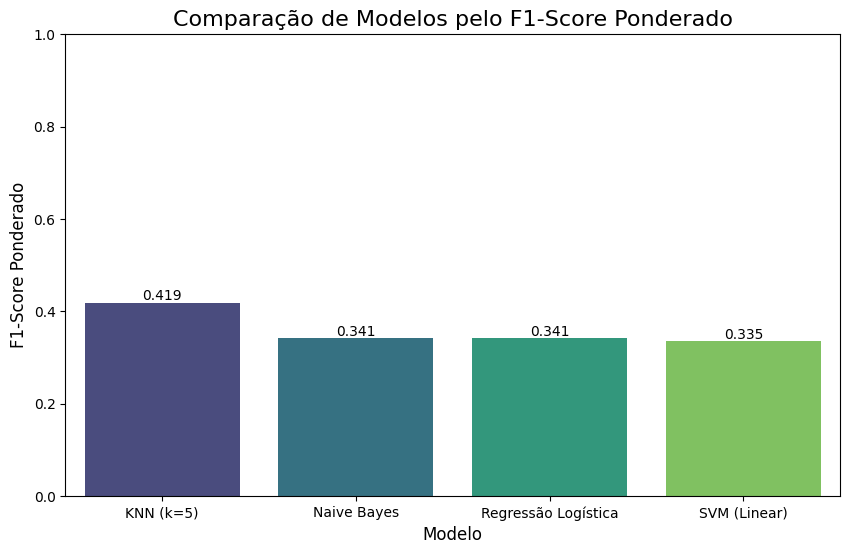

In [ ]:
print("\n--- Gerando gráfico de barras comparativo (Seaborn)... ---")

# Prepara os dados (resetar o índice para o Seaborn)
df_plot = df_comparacao.reset_index()

# Define a ordem do plot (do maior F1 para o menor)
order = df_plot.sort_values(by='F1-Score', ascending=False)['Modelo']

plt.figure(figsize=(10, 6))
barplot = sns.barplot(
    x='Modelo',
    y='F1-Score',
    data=df_plot,
    palette='viridis', # Define uma paleta de cores
    order=order
)

plt.title('Comparação de Modelos pelo F1-Score Ponderado', fontsize=16)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('F1-Score Ponderado', fontsize=12)
plt.ylim(0, 1.0) # Define o eixo Y de 0.0 a 1.0

# Adiciona os valores exatos em cima de cada barra
for p in barplot.patches:
    barplot.annotate(
        f'{p.get_height():.3f}', # Formato com 3 casas decimais
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 5),
        textcoords='offset points'
    )

# Exibe o gráfico
plt.show()

# 9. Pipeline Final: Treinamento, Otimização e Avaliação

Esta é a célula principal de execução do projeto. Ela consolida todo o fluxo de Machine Learning (nossas etapas 5 a 9) em um único pipeline:

1.  **Carrega e Vetoriza:** Faz o upload do `sentencas_rotuladas.csv` e o transforma em vetores TF-IDF (X) e rótulos numéricos (y).
2.  **Compara Baselines:** Roda a validação cruzada nos 4 modelos (SVM, KNN, etc.) e imprime a tabela comparativa para identificar o `vencedor_nome` (aquele com maior F1-Score).
3.  **Otimiza (GridSearchCV):** Pega *apenas* o modelo vencedor e executa o `GridSearchCV` para testar diferentes hiperparâmetros e encontrar a melhor configuração.
4.  **Gera Relatório Final:** Ao final, exibe o `classification_report` (detalhando Precisão/Recall por classe) e a **Matriz de Confusão** do modelo já otimizado, mostrando sua performance definitiva.

Por favor, faça o upload do arquivo 'sentencas_rotuladas.csv'.


Saving sentencas_rotuladas.csv to sentencas_rotuladas (3).csv

--- Dados Carregados: 75 sentenças válidas ---
--- Vetorização Concluída ---

--- Tabela Comparativa (Base) ---
|    | Modelo              |   F1-Score (Base) |
|---:|:--------------------|------------------:|
|  2 | KNN (k=5)           |             0.419 |
|  0 | Naive Bayes         |             0.341 |
|  3 | Regressão Logística |             0.341 |
|  1 | SVM (Linear)        |             0.335 |

--- Modelo Vencedor (Maior F1-Score): KNN (k=5) ---

Iniciando otimização (GridSearchCV) para o KNN (k=5)...
--- Otimização Concluída ---
Melhores parâmetros encontrados: {'n_neighbors': 5}
Melhor F1-Score (Ponderado) após otimização: 0.4190
Score original (base): 0.4190
Melhoria: 0.0000

--- Relatório de Classificação Detalhado (Modelo Otimizado) ---
              precision    recall  f1-score   support

    Negativo       0.25      0.26      0.26        19
      Neutro       0.52      0.68      0.59        38
    Positivo 

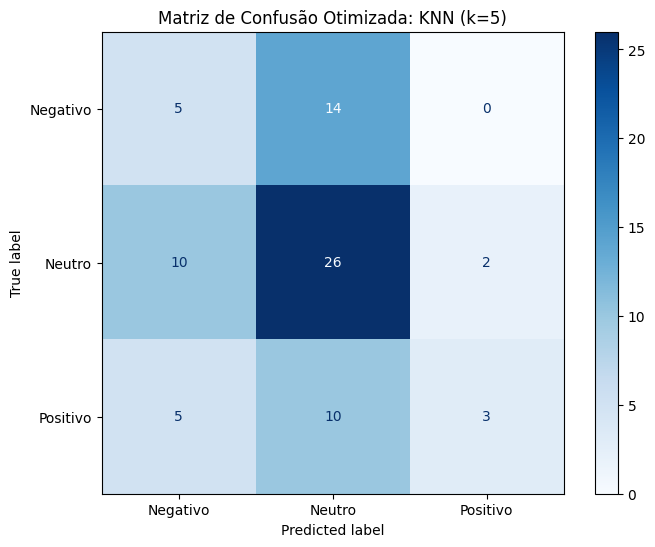

In [28]:
print("Por favor, faça o upload do arquivo 'sentencas_rotuladas.csv'.")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df_rotulado = pd.read_csv(io.BytesIO(uploaded[file_name]))
df_rotulado = df_rotulado.dropna(subset=['polaridade'])
print(f"\n--- Dados Carregados: {len(df_rotulado)} sentenças válidas ---")


# --- Etapa 5: Vetorização (Features e Labels) ---

stopwords_portuguesas = nltk.corpus.stopwords.words('portuguese')
vectorizer = TfidfVectorizer(stop_words=stopwords_portuguesas,
                             max_features=1000,
                             ngram_range=(1, 2))
X_tfidf = vectorizer.fit_transform(df_rotulado['sentenca'])

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(df_rotulado['polaridade'])
class_names = encoder.classes_

print("--- Vetorização Concluída ---")


# --- Etapa 6 e 7: Treinamento e Comparação Inicial ---

# N.B.: Definimos os modelos base aqui para referência
modelos = {
    'Naive Bayes': MultinomialNB(),
    'SVM (Linear)': SVC(kernel='linear'),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Regressão Logística': LogisticRegression(max_iter=1000)
}

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
f1_weighted_scorer = make_scorer(f1_score, average='weighted', zero_division=0)

all_model_results = []
for model_name, model in modelos.items():
    cv_f1 = np.mean(cross_validate(model, X_tfidf, y_encoded, cv=skf, scoring=f1_weighted_scorer)['test_score'])
    all_model_results.append({'Modelo': model_name, 'F1-Score (Base)': cv_f1})

df_comparacao = pd.DataFrame(all_model_results)
df_comparacao = df_comparacao.sort_values(by='F1-Score (Base)', ascending=False)

print("\n--- Tabela Comparativa (Base) ---")
print(df_comparacao.to_markdown(floatfmt=".3f"))

# Identifica o modelo vencedor
vencedor_nome = df_comparacao['Modelo'].iloc[0]
print(f"\n--- Modelo Vencedor (Maior F1-Score): {vencedor_nome} ---")


# --- Etapa 8: Otimização de Hiperparâmetros (GridSearchCV) ---

print(f"\nIniciando otimização (GridSearchCV) para o {vencedor_nome}...")

# Define os "grids" de parâmetros que queremos testar para cada modelo
param_grids = {
    'SVM (Linear)': {
        'C': [0.1, 1, 10, 50], # Testa diferentes forças de regularização
        'kernel': ['linear'] # Já sabemos que linear é bom, mas poderíamos adicionar 'rbf'
    },
    'Regressão Logística': {
        'C': [0.1, 1, 10, 50], # Força de regularização
        'solver': ['liblinear', 'saga'], # 'saga' é bom para datasets pequenos
        'penalty': ['l1', 'l2'] # Testa regularização L1 e L2
    },
    'Naive Bayes': {
        'alpha': [0.01, 0.1, 0.5, 1.0] # Parâmetro de suavização
    },
    'KNN (k=5)': {
        'n_neighbors': [3, 5, 7, 9, 11] # Testa diferentes números de vizinhos
    }
}

# Pega o modelo e o grid de parâmetros corretos para o nosso vencedor
# (Temos que recriar o modelo base para o GridSearchCV)
if vencedor_nome == 'SVM (Linear)':
    modelo_base = SVC() # O kernel será definido pelo grid
    # Atualiza o grid para testar mais kernels, já que estamos otimizando
    param_grids['SVM (Linear)']['kernel'] = ['linear', 'rbf', 'poly']
    param_grids['SVM (Linear)']['gamma'] = ['scale', 'auto']
elif vencedor_nome == 'Regressão Logística':
    modelo_base = LogisticRegression(max_iter=2000)
elif vencedor_nome == 'Naive Bayes':
    modelo_base = MultinomialNB()
elif vencedor_nome == 'KNN (k=5)':
    modelo_base = KNeighborsClassifier()

grid_para_otimizar = param_grids[vencedor_nome]

# Configura o GridSearchCV
# n_jobs=-1 usa todos os processadores para acelerar
grid_search = GridSearchCV(
    estimator=modelo_base,
    param_grid=grid_para_otimizar,
    scoring=f1_weighted_scorer,
    cv=skf,
    n_jobs=-1
)

# Executa a busca!
grid_search.fit(X_tfidf, y_encoded)

print("--- Otimização Concluída ---")
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor F1-Score (Ponderado) após otimização: {grid_search.best_score_:.4f}")

# Compara com o score original
score_original = df_comparacao.iloc[0, 1]
score_otimizado = grid_search.best_score_
print(f"Score original (base): {score_original:.4f}")
print(f"Melhoria: {(score_otimizado - score_original):.4f}")


# --- Etapa 9: Relatório Final do Modelo Otimizado ---

print("\n--- Relatório de Classificação Detalhado (Modelo Otimizado) ---")

# Pega o melhor modelo encontrado pelo GridSearch
melhor_modelo = grid_search.best_estimator_

# Usa cross_val_predict para gerar predições "fora da amostra" para cada
# ponto de dado. Isso é robusto para datasets pequenos.
y_pred_cv = cross_val_predict(melhor_modelo, X_tfidf, y_encoded, cv=skf)

# Imprime o relatório de classificação (Precisão, Recall, F1 por classe)
print(classification_report(y_encoded, y_pred_cv, target_names=class_names, zero_division=0))

print("\n--- Matriz de Confusão (Modelo Otimizado) ---")
print("Linhas = Valor Verdadeiro | Colunas = Valor Predito")

# Plota a Matriz de Confusão
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_encoded,
    y_pred_cv,
    display_labels=class_names,
    cmap='Blues',
    ax=ax
)
plt.title(f'Matriz de Confusão Otimizada: {vencedor_nome}')
plt.show()